## Weighted Least Squares with Statsmodels

In [1]:
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

from statsmodels.sandbox.regression.predstd import wls_prediction_std
from statsmodels.iolib.table import (SimpleTable, default_txt_fmt)

np.random.seed(42)

### Weighted Least Squares (WLS) Estimation

Fake data: Heteroskedasticity of 2 groups

Assumptions:

1. Misspecification: true model will be quadratic, est. linear.
2. Ind noise/error term
3. Two groups for error variance, low and high variance groups.

In [2]:
nsample = 50
x = np.linspace(0, 20, nsample)
X = np.column_stack((x, (x-5)**2))
X = sm.add_constant(X)
beta = [5., 0.5, -0.01]
sig = 0.5
w = np.ones(nsample)
w[nsample * 6//10:]=3
y_true = np.dot(X, beta)
e = np.random.normal(size=nsample)
y = y_true + sig * w * e
X = X[:, [0,1]]

### WLS Knowing the true variation of heteroscedasticity

In [3]:
mod_wls = sm.WLS(y, X, weights=1./(w**2))

In [4]:
res_wls = mod_wls.fit()
res_wls.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.899
Model:                            WLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     429.3
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.38e-25
Time:                        09:46:24   Log-Likelihood:                -54.950
No. Observations:                  50   AIC:                             113.9
Df Residuals:                      48   BIC:                             117.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3106      0.154     34.502      0.000       5.001       5.620
x1             0.4033      0.019     20.720      0.000       0.364       0.442
==============================================================================
Omnibus:                        0.228   Durbin-Watson:                   1.847
Prob(Omnibus):                  0.892   Jarque-Bera (JB):                0.132
Skew:                           0.119   Prob(JB):                        0.936
Kurtosis:                       2.920   Cond. No.                         14.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### OLS vs WLS

In [5]:
res_ols = sm.OLS(y, X).fit()
print(res_ols.params)
print(res_wls.params)

[5.55959672 0.36181418]
[5.31057184 0.40328365]


Compare WLS std error to hetero corrected OLS std errors

In [8]:
se = np.vstack([[res_wls.bse], [res_ols.bse], [res_ols.HC0_se], [res_ols.HC1_se], [res_ols.HC2_se]])
se = np.round(se, 4)
colnames = ['X1', 'const']
rownames = ['WLS', 'OLS', 'OLS_HC0', 'OLS_HC2', 'OLS_HC3']
table = SimpleTable(se, colnames, rownames, txt_fmt=default_txt_fmt)
print(table)

          X1   const 
---------------------
WLS     0.1539 0.0195
OLS     0.2907 0.0251
OLS_HC0 0.1863 0.0261
OLS_HC2 0.1901 0.0267
OLS_HC3 0.1923  0.027
---------------------


In [10]:
covb = res_ols.cov_params()
prediction_var = res_ols.mse_resid + (X * np.dot(covb, X.T).T).sum(1)
prediction_std = np.sqrt(prediction_var)
tppf = stats.t.ppf(0.975, res_ols.df_resid)

In [11]:
prstd_ols, iv_l_ols, iv_u_ols = wls_prediction_std(res_ols)

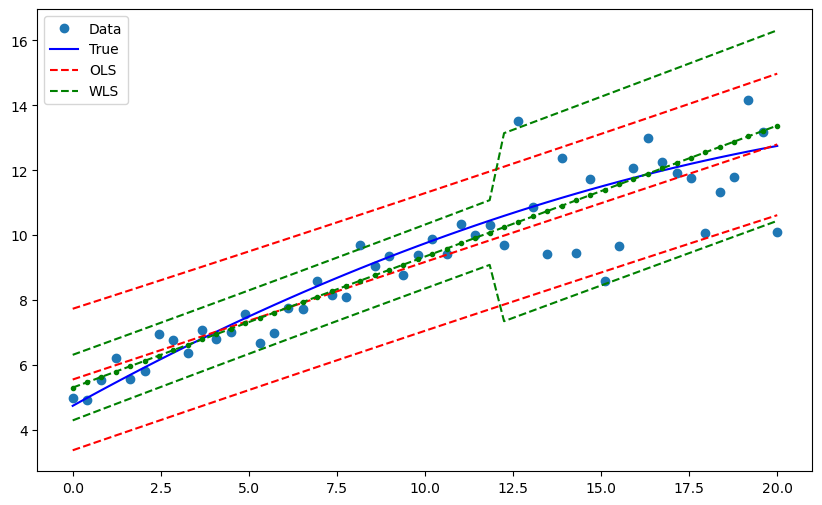

In [15]:
# Draw comparison between WLS and OLS
prstd, iv_l, iv_u = wls_prediction_std(res_wls)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(x, y, 'o', label="Data")
ax.plot(x, y_true, 'b-', label=True)

# OLS
ax.plot(x, res_ols.fittedvalues, 'r--')
ax.plot(x, iv_u_ols, 'r--', label='OLS')
ax.plot(x, iv_l_ols, 'r--')

# WLS
ax.plot(x, res_wls.fittedvalues, 'g--.')
ax.plot(x, iv_l, 'g--', label='WLS')
ax.plot(x, iv_u, 'g--')
ax.legend(loc='best')
plt.show()